# Data Preparation — Dataset MBG (Program Makan Bergizi Gratis)

**Notebook:** `01_data_preparation.ipynb`  
**Peneliti:** Khoeru Roziqin  
**Tanggal:** 01-04-26  

---

## Deskripsi

Notebook ini menggabungkan seluruh tahap persiapan data sebelum anotasi:
penggabungan raw CSV, normalisasi format `created_at`, pembersihan, deduplikasi,
hingga stratified sampling berbasis periode.
Output akhir berupa `mbg_sampled.csv` yang siap masuk ke tahap anotasi manual.

## Alur Pipeline

```
Raw CSV (keyword MBG + Makan Bergizi Gratis)
        ↓
1. Load & Normalisasi       → gabungkan CSV, normalisasi created_at ke tz-naive
2. Filter & Deduplikasi     → keyword, tanggal, ID, teks, spam
3. Merge & Inspeksi         → gabung lintas-keyword, inspeksi df_full, pre-filter
4. Visualisasi Tren         → harian dan bulanan per dataset dan per keyword
5. Assign Periode           → mapping ke period_1 s/d period_12
6. Stratified Sampling      → 570 tweet/periode (500 target + 70 buffer)
7. Distribusi & Validasi    → distribusi hasil sampling (by period & by month)
8. Export Output            → mbg_sampled.csv (sorted ascending by created_at)
9. EDA Token Length         → distribusi panjang token vs max_len = 128
```

## Definisi Periode & Bulan

Rentang data: **6 Januari 2025 – 6 Januari 2026**.  
Dua dimensi waktu digunakan secara terpisah:

**Period** (12 periode, berbasis tanggal 6):

| Periode | Rentang |
|---|---|
| period_1 | 6 Jan 2025 – 5 Feb 2025 |
| period_2 | 6 Feb 2025 – 5 Mar 2025 |
| ... | ... |
| period_12 | 6 Des 2025 – 6 Jan 2026 |

**Bulan Kalender** (13 bulan, berbasis bulan aktual `created_at`):
Jan 2025, Feb 2025, ..., Des 2025, Jan 2026

## Normalisasi Format `created_at`

Raw data mengandung dua format timestamp:
- **ISO 8601**: `2025-10-07T23:59:35.000Z`
- **Twitter format**: `Wed Jan 08 23:26:55 +0000 2025`

Seluruh format dinormalisasi ke **tz-naive UTC** di awal pipeline.

**Referensi:**  
Cochran, W.G. (1977). *Sampling Techniques* (3rd ed.). John Wiley & Sons.  
Babbie, E. (2010). *The Practice of Social Research* (12th ed.). Wadsworth.  
Pustejovsky, J. & Stubbs, A. (2012). *Natural Language Annotation for Machine Learning*. O'Reilly.  
Jurafsky, D. & Martin, J.H. (2023). *Speech and Language Processing* (3rd ed. draft).

## 0. Setup & Mount Google Drive

Import seluruh library yang dibutuhkan dan mount Google Drive sebagai sumber data.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print('✅ Library berhasil dimuat.')
print(f'   Pandas  : {pd.__version__}')
print(f'   NumPy   : {np.__version__}')

Mounted at /content/drive
✅ Library berhasil dimuat.
   Pandas  : 2.2.2
   NumPy   : 2.0.2


## 1. Konfigurasi Global

Seluruh path, parameter, dan konstanta didefinisikan terpusat di satu sel.
Semua timestamp internal menggunakan format **tz-naive** setelah normalisasi.

> **Dimensi waktu:**  
> - **Period** (12): berbasis tanggal 6, digunakan untuk stratified sampling  
> - **Bulan kalender** (13): Jan 2025–Jan 2026, digunakan untuk visualisasi distribusi

In [2]:
# ── PATH ──────────────────────────────────────────────────────────────────────
BASE_DIR           = '/content/drive/My Drive/skripsi/dataset/mbg_2025'
RAW_DATA_MBG_DIR   = os.path.join(BASE_DIR, 'raw_data', 'mbg')
RAW_DATA_MAKAN_DIR = os.path.join(BASE_DIR, 'raw_data', 'makan_bergizi_gratis')
MERGED_OUTPUT_DIR  = os.path.join(BASE_DIR, 'merged_data')
PROCESSED_DIR      = os.path.join(BASE_DIR, 'processed')
MERGED_MAKAN_PATH  = os.path.join(MERGED_OUTPUT_DIR, 'merged_makan_bergizi_gratis.csv')
MERGED_MBG_PATH    = os.path.join(MERGED_OUTPUT_DIR, 'merged_mbg.csv')
MERGED_FULL_PATH   = os.path.join(MERGED_OUTPUT_DIR, 'merged_mbg_full.csv')
MERGED_FULL_CLEAN_PATH = os.path.join(MERGED_OUTPUT_DIR, 'merged_mbg_full_clean.csv')
OUTPUT_PATH        = os.path.join(PROCESSED_DIR,     'mbg_sampled.csv')
os.makedirs(MERGED_OUTPUT_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR,     exist_ok=True)

# ── RENTANG WAKTU (tz-naive) ──────────────────────────────────────────────────
PIPELINE_START = pd.Timestamp('2025-01-06')   # inklusif
PIPELINE_END   = pd.Timestamp('2026-01-07')   # eksklusif (< operator)

# ── DEFINISI 12 PERIODE (berbasis tanggal 6) ──────────────────────────────────
# period_1  : [2025-01-06, 2025-02-06)  → 6 Jan – 5 Feb 2025
# period_2  : [2025-02-06, 2025-03-06)  → 6 Feb – 5 Mar 2025
# ...
# period_12 : [2025-12-06, 2026-01-07)  → 6 Des 2025 – 6 Jan 2026
PERIOD_START_STRS = [f'2025-{m:02d}-06' for m in range(1, 13)]
PERIOD_END_STRS   = [
    f'2025-{m+1:02d}-06' if m < 12 else '2026-01-07'
    for m in range(1, 13)
]
PERIOD_LABELS = [f'period_{i}' for i in range(1, 13)]

# ── DEFINISI 13 BULAN KALENDER (Jan 2025 – Jan 2026) ─────────────────────────
# Digunakan untuk visualisasi distribusi berdasarkan bulan aktual created_at.
# Berbeda dari period: bulan kalender mengikuti batas tanggal 1 setiap bulan.
MONTH_LABELS = [
    'Jan 2025', 'Feb 2025', 'Mar 2025', 'Apr 2025',
    'Mei 2025', 'Jun 2025', 'Jul 2025', 'Agu 2025',
    'Sep 2025', 'Okt 2025', 'Nov 2025', 'Des 2025',
    'Jan 2026'
]
# Kunci untuk groupby bulan: format 'YYYY-MM'
MONTH_KEYS = [
    '2025-01','2025-02','2025-03','2025-04',
    '2025-05','2025-06','2025-07','2025-08',
    '2025-09','2025-10','2025-11','2025-12',
    '2026-01'
]
MONTH_KEY_TO_LABEL = dict(zip(MONTH_KEYS, MONTH_LABELS))

# ── KEYWORD ───────────────────────────────────────────────────────────────────
KEYWORDS_MAKAN = [
    'makan bergizi gratis', 'makan bergizi',
    'makan siang gratis',   'program makan gratis'
]
KEYWORDS_MBG = ['mbg']

# ── SPAM KEYWORDS ─────────────────────────────────────────────────────────────
SPAM_KEYWORDS = [
    'slot', 'gacor', 'zeus', 'pragmatic', 'maxwin', 'wd', 'depo',
    'pola gacor', 'rtp', 'judol', 'link daftar', 'situs',
    'shopee', 'tokopedia', 'lazada', 'blibli', 'cek keranjang',
    'spaylater', 'dana kaget', 'giveaway', 'racun', 'link di bio',
    'affiliate', 'open joki', 'joki tugas', 'jasjok', 'convert pulsa',
    'mutualan', 'follback', 'biro jodoh',
    'open bo', 'vcs', 'video syur', 'museum', 'boke', 'desah', 'colmek'
]
SPAM_REGEX_PATTERN = '|'.join(SPAM_KEYWORDS)

# ── PARAMETER SAMPLING ────────────────────────────────────────────────────────
SAMPLE_PER_PERIOD = 570   # 500 target + 70 buffer (14% cadangan)
MIN_WORD_COUNT    = 3

# ── KOLOM OUTPUT ──────────────────────────────────────────────────────────────
COLS_KEEP = [
    'id_str', 'conversation_id_str', 'created_at',
    'full_text', 'username', 'user_id_str',
    'favorite_count', 'retweet_count', 'reply_count', 'quote_count',
    'lang', 'location', 'source_keyword'
]

# ── Print ringkasan konfigurasi ───────────────────────────────────────────────
print('✅ Konfigurasi berhasil dimuat.')
print(f'   Base dir        : {BASE_DIR}')
print(f'   Sampel/periode  : {SAMPLE_PER_PERIOD} (500 target + 70 buffer = 14%)')
print(f'   Jumlah periode  : {len(PERIOD_LABELS)} periode (berbasis tanggal 6)')
print(f'   Jumlah bulan    : {len(MONTH_LABELS)} bulan kalender (Jan 2025 – Jan 2026)')
print(f'   Timestamp mode  : tz-naive UTC')
print()
print(f'   {"Periode":<12} {"Rentang"}')
print(f'   {"-"*50}')
for lbl, ps, pe in zip(PERIOD_LABELS, PERIOD_START_STRS, PERIOD_END_STRS):
    pe_disp = '06 Jan 2026' if lbl == 'period_12' else pd.Timestamp(pe).strftime('%d %b %Y')
    print(f'   {lbl:<12} {pd.Timestamp(ps).strftime("%d %b %Y")} – {pe_disp}')
print()
print(f'   Bulan kalender  : {", ".join(MONTH_LABELS)}')

✅ Konfigurasi berhasil dimuat.
   Base dir        : /content/drive/My Drive/skripsi/dataset/mbg_2025
   Sampel/periode  : 570 (500 target + 70 buffer = 14%)
   Jumlah periode  : 12 periode (berbasis tanggal 6)
   Jumlah bulan    : 13 bulan kalender (Jan 2025 – Jan 2026)
   Timestamp mode  : tz-naive UTC

   Periode      Rentang
   --------------------------------------------------
   period_1     06 Jan 2025 – 06 Feb 2025
   period_2     06 Feb 2025 – 06 Mar 2025
   period_3     06 Mar 2025 – 06 Apr 2025
   period_4     06 Apr 2025 – 06 May 2025
   period_5     06 May 2025 – 06 Jun 2025
   period_6     06 Jun 2025 – 06 Jul 2025
   period_7     06 Jul 2025 – 06 Aug 2025
   period_8     06 Aug 2025 – 06 Sep 2025
   period_9     06 Sep 2025 – 06 Oct 2025
   period_10    06 Oct 2025 – 06 Nov 2025
   period_11    06 Nov 2025 – 06 Dec 2025
   period_12    06 Dec 2025 – 06 Jan 2026

   Bulan kalender  : Jan 2025, Feb 2025, Mar 2025, Apr 2025, Mei 2025, Jun 2025, Jul 2025, Agu 2025, Sep 2025, 

## 2. Fungsi Pipeline Pengolahan Raw Data

Seluruh fungsi modular didefinisikan di sini. Fungsi `normalize_created_at`
dipanggil pertama sebelum semua operasi pada kolom `created_at`.

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# NORMALISASI TIMESTAMP — Dipanggil PERTAMA sebelum operasi apapun
# ══════════════════════════════════════════════════════════════════════════════

def normalize_created_at(df):
    """
    Normalisasi kolom created_at ke format tz-naive UTC.

    Menangani format timestamp raw data Twitter:
      - ISO 8601  : '2025-10-07T23:59:35.000Z'
      - Twitter   : 'Wed Jan 08 23:26:55 +0000 2025'

    Proses:
      Step 1: parse semua format → UTC timezone-aware (format='mixed')
      Step 2: buang baris dengan created_at tidak dapat diparsing (NaT)
      Step 3: strip timezone → tz-naive (nilai tetap UTC)
    """
    n_before = len(df)
    df = df.copy()
    df['created_at'] = pd.to_datetime(
        df['created_at'], errors='coerce', format='mixed', utc=True
    )
    df = df.dropna(subset=['created_at'])
    n_dropped = n_before - len(df)
    if n_dropped > 0:
        print(f'  ⚠️  {n_dropped:,} baris dibuang (created_at tidak dapat diparsing)')
    df['created_at'] = df['created_at'].dt.tz_localize(None)
    return df


# ══════════════════════════════════════════════════════════════════════════════
# FUNGSI PIPELINE
# ══════════════════════════════════════════════════════════════════════════════

def load_and_merge_csv(folder_path):
    """Membaca semua file CSV dalam folder dan menggabungkannya."""
    all_files = glob.glob(os.path.join(folder_path, '*.csv'))
    if not all_files:
        print(f'  ⚠️  Tidak ada file CSV di: {folder_path}')
        return pd.DataFrame()
    df_list = []
    for fp in all_files:
        try:
            df_raw = pd.read_csv(fp, on_bad_lines='skip', lineterminator='\n',
                                  encoding_errors='ignore', low_memory=False)
            df_list.append(df_raw)
        except Exception as e:
            print(f'  ❌ Gagal membaca {os.path.basename(fp)}: {e}')
    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()


def standardize_columns(df):
    """Standarisasi nama kolom dan normalisasi anomali kolom username."""
    df = df.copy()
    df.rename(columns={'date': 'created_at', 'text': 'full_text'},
              inplace=True, errors='ignore')
    anomaly_cols = ['username', 'username\r', 'username;;;;;;;\r']
    if 'username' not in df.columns:
        df['username'] = pd.NA
    for col in anomaly_cols:
        if col in df.columns and col != 'username':
            df[col] = df[col].replace(r'^\s*$', pd.NA, regex=True)
            df['username'] = df['username'].replace(r'^\s*$', pd.NA, regex=True)
            df['username'] = df['username'].combine_first(df[col])
    df.drop(columns=[c for c in anomaly_cols if c != 'username'],
            inplace=True, errors='ignore')
    if 'id_str' in df.columns:
        df['id_str'] = df['id_str'].astype(str)
        df['id_str'] = df['id_str'].replace(r'\.?0$', '', regex=True)
        df.loc[df['id_str'].isin(['nan', '<NA>']), 'id_str'] = ''
    else:
        print('  ⚠️  Kolom id_str tidak ditemukan.')
        df['id_str'] = ''
    return df


def filter_by_required_keywords(df, required_keywords):
    """Filter baris yang mengandung minimal satu keyword yang disyaratkan."""
    pattern = '|'.join(required_keywords)
    mask    = df['full_text'].astype(str).str.contains(pattern, case=False, na=False)
    return df[mask].copy()


def filter_by_date(df, start_ts, end_ts):
    """
    Filter berdasarkan rentang timestamp.
    Asumsi: created_at sudah tz-naive.
    """
    start = pd.Timestamp(start_ts)
    end   = pd.Timestamp(end_ts)
    if start.tzinfo is not None: start = start.tz_localize(None)
    if end.tzinfo   is not None: end   = end.tz_localize(None)
    return df[(df['created_at'] >= start) & (df['created_at'] < end)].copy()


def remove_id_duplicates(df):
    """Hapus duplikat berdasarkan primary key (id_str)."""
    df = df[df['id_str'] != ''].copy()
    df.drop_duplicates(subset=['id_str'], keep='first', inplace=True)
    return df


def remove_advanced_duplicates(df):
    """Hapus duplikat teks setelah normalisasi URL, mention, hashtag, tanda baca."""
    temp = df['full_text'].astype(str).str.lower()
    temp = temp.str.replace(r'http\S+|www\S+|https\S+', '', regex=True)
    temp = temp.str.replace(r'@\w+',    '', regex=True)
    temp = temp.str.replace(r'#\w+',    '', regex=True)
    temp = temp.str.replace(r'[^\w\s]', '', regex=True)
    temp = temp.str.replace(r'\s+', ' ', regex=True).str.strip()
    df   = df.copy()
    df['_temp_dedup'] = temp
    df = df[df['_temp_dedup'] != '']
    df.drop_duplicates(subset=['_temp_dedup'], keep='first', inplace=True)
    df.drop(columns=['_temp_dedup'], inplace=True)
    return df


def remove_spam(df):
    """Hapus baris yang mengandung kata kunci spam."""
    is_spam = df['full_text'].astype(str).str.contains(
        SPAM_REGEX_PATTERN, case=False, na=False)
    return df[~is_spam].copy()


def assign_period(created_at_series):
    """
    Memetakan setiap timestamp ke label period_1 s/d period_12.

    Berbasis tanggal 6 setiap bulan (bukan bulan kalender):
      period_1  : [2025-01-06, 2025-02-06)  → 6 Jan – 5 Feb 2025
      period_2  : [2025-02-06, 2025-03-06)  → 6 Feb – 5 Mar 2025
      ...
      period_12 : [2025-12-06, 2026-01-07)  → 6 Des 2025 – 6 Jan 2026

    Asumsi: created_at sudah tz-naive.
    Data di luar 12 periode dikembalikan sebagai pd.NA.
    """
    result = pd.Series(pd.NA, index=created_at_series.index, dtype='object')
    for lbl, ps_str, pe_str in zip(PERIOD_LABELS, PERIOD_START_STRS, PERIOD_END_STRS):
        ps   = pd.Timestamp(ps_str)
        pe   = pd.Timestamp(pe_str)
        mask = (created_at_series >= ps) & (created_at_series < pe)
        result[mask] = lbl
    return result


def get_month_key(created_at_series):
    """
    Mengekstrak bulan kalender dari created_at sebagai string 'YYYY-MM'.

    Berbeda dari assign_period:
      - Tidak berbasis tanggal 6, melainkan bulan aktual
      - Menghasilkan 13 bulan (Jan 2025 – Jan 2026)
      - Digunakan untuk visualisasi distribusi berdasarkan bulan kalender
    """
    return created_at_series.dt.strftime('%Y-%m')


def print_summary_by_keyword(df, label='Dataset'):
    """Cetak ringkasan total data dan breakdown per source_keyword."""
    print(f'  Total {label:<28}: {len(df):>8,} tweet')
    if 'source_keyword' in df.columns:
        col = df['source_keyword']
        if isinstance(col, pd.DataFrame):
            col = col.iloc[:, 0]
        for kw, cnt in col.value_counts().items():
            print(f'    └─ [{kw:<26}]: {cnt:>8,} tweet')


def process_pipeline(folder_path, source_label, required_keywords):
    """
    Pipeline utama per kelompok keyword:
      load → standardize → normalize_created_at → filter keyword
      → filter date → dedup ID → dedup teks → remove spam → sort
    """
    print(f'\n{"-"*62}')
    print(f' Processing: {source_label}')
    print(f'{"-"*62}')

    df = load_and_merge_csv(folder_path)
    if df.empty: return df

    n0 = len(df)
    print(f'  [1] Raw CSV loaded           : {n0:>8,} baris')

    df = standardize_columns(df)
    if 'full_text' not in df.columns or 'created_at' not in df.columns:
        print('  ❌ Kolom full_text/created_at tidak ditemukan.')
        return pd.DataFrame()

    # Normalisasi created_at — WAJIB sebelum semua operasi timestamp
    df = normalize_created_at(df)
    if df.empty:
        print('  ❌ Semua baris dibuang setelah normalisasi.')
        return pd.DataFrame()
    n1 = len(df)
    print(f'  [2] Setelah normalisasi ts   : {n1:>8,} baris  (−{n0-n1:,} tidak valid)')

    df = filter_by_required_keywords(df, required_keywords)
    n2 = len(df)
    print(f'  [3] Setelah filter keyword   : {n2:>8,} baris  (−{n1-n2:,} mismatch)')

    df = filter_by_date(df, PIPELINE_START, PIPELINE_END)
    n3 = len(df)
    print(f'  [4] Setelah filter tanggal   : {n3:>8,} baris  (−{n2-n3:,} out of range)')

    df = remove_id_duplicates(df)
    n4 = len(df)
    print(f'  [5] Dedup by ID              : {n4:>8,} baris  (−{n3-n4:,} duplikat ID)')

    df = remove_advanced_duplicates(df)
    n5 = len(df)
    print(f'  [6] Dedup by teks            : {n5:>8,} baris  (−{n4-n5:,} duplikat teks)')

    df = remove_spam(df)
    n6 = len(df)
    print(f'  [7] Setelah hapus spam       : {n6:>8,} baris  (−{n5-n6:,} spam)')

    df = df.sort_values(by='created_at', ascending=True).reset_index(drop=True)
    df['source_keyword'] = source_label
    print(f'  ✅ FINAL [{source_label:<24}]: {len(df):>8,} baris')
    return df


print('✅ Seluruh fungsi pipeline berhasil didefinisikan.')
print('   normalize_created_at : ISO 8601 + Twitter format → tz-naive UTC')
print('   assign_period        : 12 periode berbasis tanggal 6')
print('   get_month_key        : 13 bulan kalender Jan 2025 – Jan 2026')
print('   process_pipeline     : load → normalize → filter → dedup → spam → sort')

✅ Seluruh fungsi pipeline berhasil didefinisikan.
   normalize_created_at : ISO 8601 + Twitter format → tz-naive UTC
   assign_period        : 12 periode berbasis tanggal 6
   get_month_key        : 13 bulan kalender Jan 2025 – Jan 2026
   process_pipeline     : load → normalize → filter → dedup → spam → sort


## 3. Eksekusi Pipeline, Penggabungan, Inspeksi & Pre-filter

Pipeline dijalankan per kelompok keyword, digabungkan dan dideduplikasi lintas-dataset.
Inspeksi `df_full` ditampilkan setelah merge selesai (sebelum pre-filter).
Pre-filter kemudian diaplikasikan menghasilkan `df` yang siap masuk ke sampling.

In [4]:
# ── Eksekusi pipeline per kelompok keyword ────────────────────────────────────
df_makan = process_pipeline(RAW_DATA_MAKAN_DIR, 'makan_bergizi_gratis', KEYWORDS_MAKAN)
df_mbg   = process_pipeline(RAW_DATA_MBG_DIR,   'mbg',                  KEYWORDS_MBG)

# ── Gabungkan dua dataset ─────────────────────────────────────────────────────
print(f'\n{"-"*62}')
print(' Penggabungan Lintas-Dataset')
print(f'{"-"*62}')

df_full = pd.concat([df_makan, df_mbg], axis=0, ignore_index=True)
df_full = df_full.loc[:, ~df_full.columns.duplicated()]

n_concat = len(df_full)
print(f'  Setelah concat             : {n_concat:>8,} baris')
print_summary_by_keyword(df_full, 'setelah concat')

dup_id = df_full.duplicated(subset=['id_str']).sum()
if dup_id > 0:
    df_full.drop_duplicates(subset=['id_str'], keep='first', inplace=True)
print(f'  Dedup ID lintas-dataset    : {len(df_full):>8,} baris  (−{dup_id:,} duplikat)')

dup_txt = df_full.duplicated(subset=['full_text']).sum()
if dup_txt > 0:
    df_full.drop_duplicates(subset=['full_text'], keep='first', inplace=True)
print(f'  Dedup teks lintas-dataset  : {len(df_full):>8,} baris  (−{dup_txt:,} duplikat)')

df_full = df_full.sort_values(by='created_at', ascending=True).reset_index(drop=True)
print(f'\n  ✅ MERGED FULL FINAL (sorted asc): {len(df_full):>8,} baris')
print_summary_by_keyword(df_full, 'merged full')

# ── Simpan output merge ───────────────────────────────────────────────────────
if not df_makan.empty:
    df_makan.sort_values('created_at').to_csv(MERGED_MAKAN_PATH, index=False)
    print(f'\n  💾 Saved: {MERGED_MAKAN_PATH}')
if not df_mbg.empty:
    df_mbg.sort_values('created_at').to_csv(MERGED_MBG_PATH, index=False)
    print(f'  💾 Saved: {MERGED_MBG_PATH}')
if not df_full.empty:
    df_full.to_csv(MERGED_FULL_PATH, index=False)
    print(f'  💾 Saved: {MERGED_FULL_PATH}')

# ── Inspeksi df_full (sebelum pre-filter) ─────────────────────────────────────
print(f'\n{"="*62}')
print(' INSPEKSI DATASET GABUNGAN (sebelum pre-filter)')
print(f'{"="*62}')
print(f'\nShape  : {df_full.shape[0]:,} baris × {df_full.shape[1]} kolom')
print(f'Kolom  : {list(df_full.columns)}')
print(f'\nMissing values per kolom:')
print(df_full.isnull().sum())
print(f'\nRentang waktu (tz-naive UTC):')
print(f'  Terlama : {df_full["created_at"].min()}')
print(f'  Terbaru : {df_full["created_at"].max()}')
print(f'  dtype   : {df_full["created_at"].dtype}  ← harus datetime64[ns], tz-naive')
print(f'\n📊 Distribusi berdasarkan keyword:')
print_summary_by_keyword(df_full, 'dataset gabungan')
print(f'\nPreview 3 baris pertama:')
display(df_full[['id_str','created_at','full_text','source_keyword']].head(3))
print(f'\nPreview 3 baris terakhir:')
display(df_full[['id_str','created_at','full_text','source_keyword']].tail(3))

# ── Pre-filter ────────────────────────────────────────────────────────────────
print(f'\n{"-"*62}')
print(' Pre-filter untuk Sampling')
print(f'{"-"*62}')

cols_needed = list(dict.fromkeys(
    [c for c in COLS_KEEP if c in df_full.columns] + ['source_keyword']
))
df = df_full[[c for c in cols_needed if c in df_full.columns]].copy()
df = df.loc[:, ~df.columns.duplicated()]

n_pf0 = len(df)
print(f'\n  [0] Data masuk pre-filter      : {n_pf0:>8,} tweet')
print_summary_by_keyword(df, 'masuk pre-filter')

df = df.dropna(subset=['full_text'])
df['full_text'] = df['full_text'].astype(str).str.strip()
df = df[df['full_text'] != '']
n_pf1 = len(df)
print(f'\n  [1] Setelah filter null/kosong : {n_pf1:>8,} tweet  (−{n_pf0-n_pf1:,})')
print_summary_by_keyword(df, 'setelah filter null')

df['word_count'] = df['full_text'].str.split().str.len()
df = df[df['word_count'] > MIN_WORD_COUNT]
n_pf2 = len(df)
print(f'\n  [2] Setelah filter panjang >{MIN_WORD_COUNT}  : {n_pf2:>8,} tweet  (−{n_pf1-n_pf2:,})')
print_summary_by_keyword(df, 'siap sampling')

df = df.sort_values(by='created_at', ascending=True).reset_index(drop=True)
print(f'\n  ✅ Total data siap sampling (sorted asc): {len(df):,} tweet')

# ── Simpan output Pre-filter ──────────────────────────────────
if not df.empty:
    df.to_csv(MERGED_FULL_CLEAN_PATH, index=False)
    print(f'  💾 Saved Clean Data: {MERGED_FULL_CLEAN_PATH}')


--------------------------------------------------------------
 Processing: makan_bergizi_gratis
--------------------------------------------------------------
  [1] Raw CSV loaded           :   70,075 baris
  [2] Setelah normalisasi ts   :   70,075 baris  (−0 tidak valid)
  [3] Setelah filter keyword   :   65,077 baris  (−4,998 mismatch)
  [4] Setelah filter tanggal   :   65,077 baris  (−0 out of range)
  [5] Dedup by ID              :   59,924 baris  (−5,153 duplikat ID)
  [6] Dedup by teks            :   45,368 baris  (−14,556 duplikat teks)
  [7] Setelah hapus spam       :   41,933 baris  (−3,435 spam)
  ✅ FINAL [makan_bergizi_gratis    ]:   41,933 baris

--------------------------------------------------------------
 Processing: mbg
--------------------------------------------------------------
  [1] Raw CSV loaded           :  101,934 baris
  [2] Setelah normalisasi ts   :  101,934 baris  (−0 tidak valid)
  [3] Setelah filter keyword   :   96,559 baris  (−5,375 mismatch)
  [4] S

,id_str,created_at,full_text,source_keyword
0,1876056231879794875,2025-01-06 00:00:35,Harga satuan porsi MBG tersebut sebelumnya men...,mbg
1,1876061235705446463,2025-01-06 00:20:28,"Program prioritas Presiden Prabowo Subianto, y...",mbg
2,1876062574028238974,2025-01-06 00:25:47,@budimandjatmiko @prabowo Bud...Bud...darimana...,mbg



Preview 3 baris terakhir:


,id_str,created_at,full_text,source_keyword
119377,2008689473237012657,2026-01-06 23:57:44,"Makan bergizi, generasi prestasi! Dukung Progr...",mbg
119378,2008689773586903399,2026-01-06 23:58:56,@BBCIndonesia MBG hadir gak?,mbg
119379,2008689992898629661,2026-01-06 23:59:48,@mhuseinali Kerja Nyata MBG dan ketring di lap...,mbg



--------------------------------------------------------------
 Pre-filter untuk Sampling
--------------------------------------------------------------

  [0] Data masuk pre-filter      :  119,380 tweet
  Total masuk pre-filter            :  119,380 tweet
    └─ [mbg                       ]:   77,447 tweet
    └─ [makan_bergizi_gratis      ]:   41,933 tweet

  [1] Setelah filter null/kosong :  119,380 tweet  (−0)
  Total setelah filter null         :  119,380 tweet
    └─ [mbg                       ]:   77,447 tweet
    └─ [makan_bergizi_gratis      ]:   41,933 tweet

  [2] Setelah filter panjang >3  :  118,340 tweet  (−1,040)
  Total siap sampling               :  118,340 tweet
    └─ [mbg                       ]:   76,407 tweet
    └─ [makan_bergizi_gratis      ]:   41,933 tweet

  ✅ Total data siap sampling (sorted asc): 118,340 tweet
  💾 Saved Clean Data: /content/drive/My Drive/skripsi/dataset/mbg_2025/merged_data/merged_mbg_full_clean.csv


## 4. Visualisasi Tren Dataset Gabungan

Tren volume tweet harian dan bulanan untuk memahami pola temporal data.

In [5]:
def plot_timeline(df_list, labels, title, save_path=None):
    fig, ax = plt.subplots(figsize=(15, 5))
    colors  = ['#534AB7', '#E24B4A', '#1D9E75']
    for i, (df_plot, label) in enumerate(zip(df_list, labels)):
        if df_plot.empty: continue
        daily = df_plot.set_index('created_at').resample('D').size()
        ax.plot(daily.index, daily.values, label=label,
                color=colors[i % len(colors)], alpha=0.85, linewidth=1.4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b-%y'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=14))
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel('Tanggal', fontsize=11)
    ax.set_ylabel('Jumlah Tweet', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.legend(fontsize=10); ax.grid(True, alpha=0.25)
    plt.xticks(rotation=45); sns.despine(); plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_monthly(df_list, labels, title, save_path=None):
    combined = pd.DataFrame()
    for df_plot, label in zip(df_list, labels):
        if df_plot.empty: continue
        monthly = df_plot.set_index('created_at').resample('ME').size()
        monthly.index = monthly.index.strftime('%b %y')
        combined[label] = monthly
    if combined.empty:
        print('⚠️  Tidak ada data.'); return
    colors = ['#534AB7', '#E24B4A']
    ax = combined.plot(kind='bar', figsize=(13, 5), color=colors[:len(labels)],
                       width=0.8, alpha=0.9, edgecolor='none')
    ax.set_title(title, fontsize=13, pad=12)
    ax.set_xlabel('Bulan', fontsize=11)
    ax.set_ylabel('Jumlah Tweet', fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.xticks(rotation=0, fontsize=9); ax.grid(axis='y', alpha=0.25)
    for p in ax.patches:
        h = p.get_height()
        if pd.notnull(h) and h > 0:
            ax.annotate(f'{int(h):,}', (p.get_x()+p.get_width()/2, h),
                        ha='center', va='bottom', xytext=(0,4),
                        textcoords='offset points', fontsize=7)
    ax.legend(fontsize=10); sns.despine(); plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

📊 Tren Keseluruhan — Dataset Gabungan



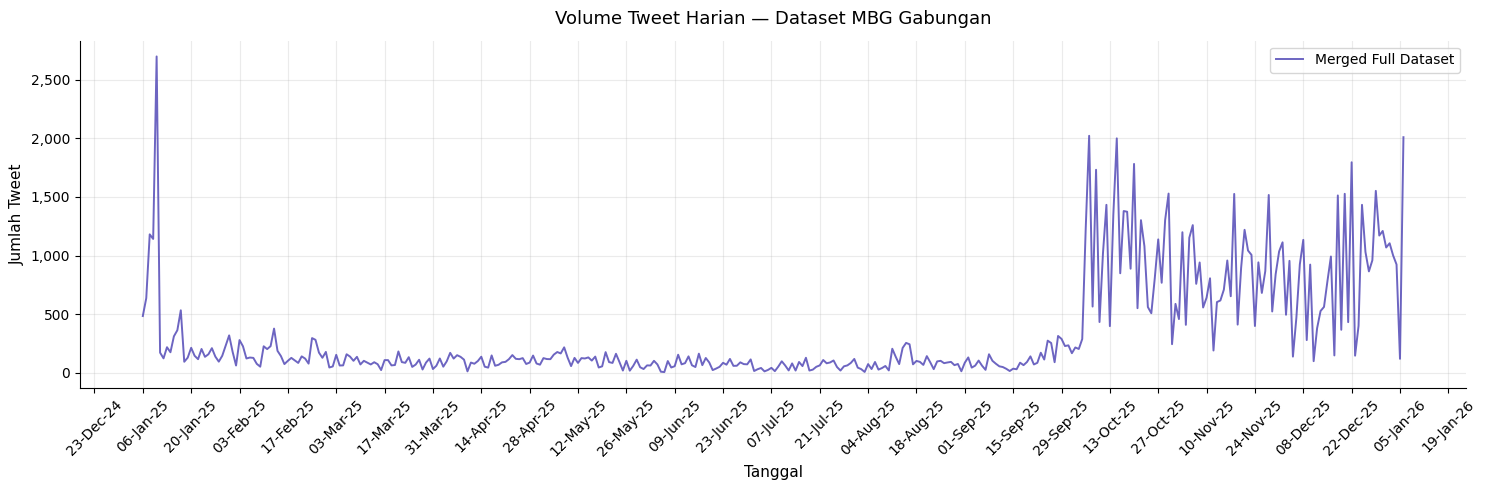

In [6]:
print('📊 Tren Keseluruhan — Dataset Gabungan\n')
plot_timeline([df_full], ['Merged Full Dataset'],
              'Volume Tweet Harian — Dataset MBG Gabungan',
              f'{PROCESSED_DIR}/trend_harian_full.png')

📊 Tren Keseluruhan — Dataset Gabungan



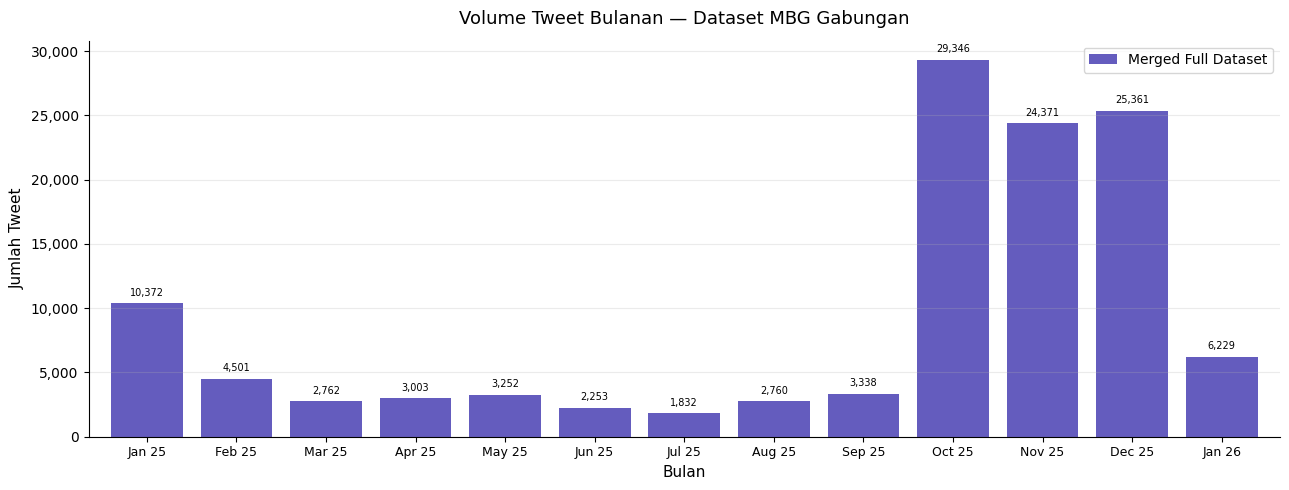

In [7]:
print('📊 Tren Keseluruhan — Dataset Gabungan\n')
plot_monthly([df_full], ['Merged Full Dataset'],
             'Volume Tweet Bulanan — Dataset MBG Gabungan',
             f'{PROCESSED_DIR}/trend_bulanan_full.png')

📊 Tren per Keyword



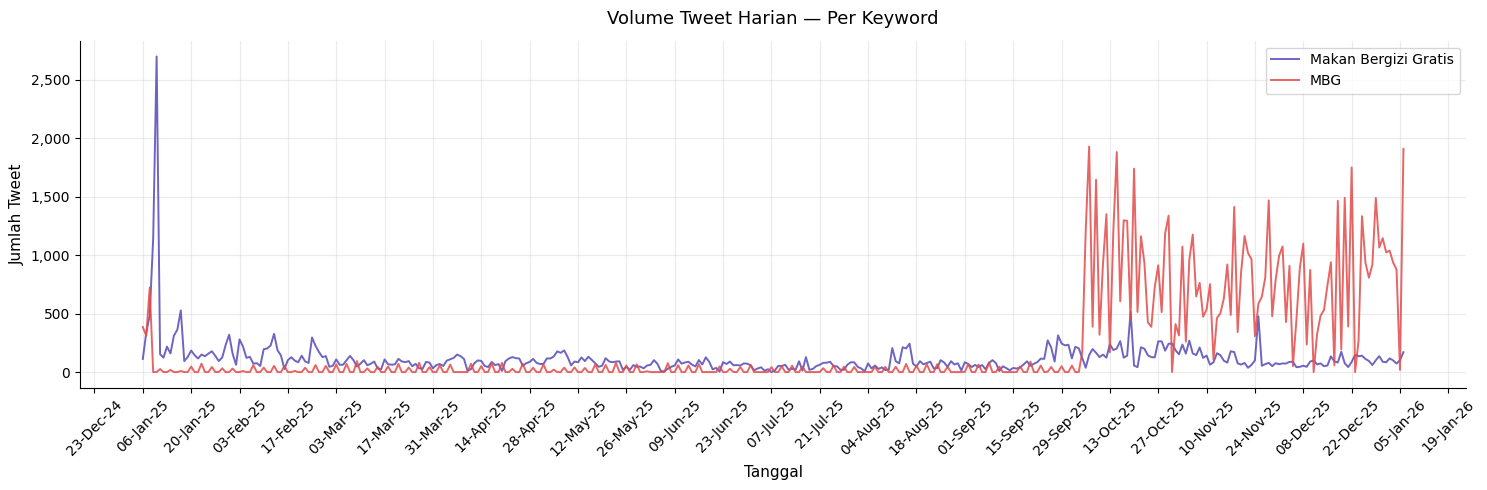

In [8]:
print('📊 Tren per Keyword\n')
plot_timeline([df_makan, df_mbg], ['Makan Bergizi Gratis', 'MBG'],
              'Volume Tweet Harian — Per Keyword',
              f'{PROCESSED_DIR}/trend_harian_per_keyword.png')

📊 Tren per Keyword



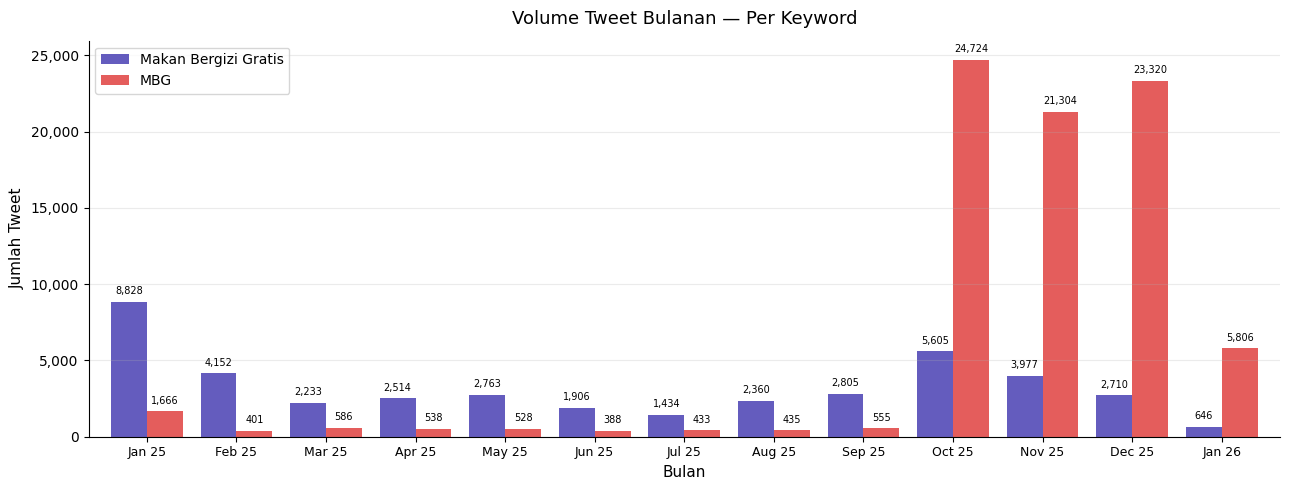

In [9]:
print('📊 Tren per Keyword\n')
plot_monthly([df_makan, df_mbg], ['Makan Bergizi Gratis', 'MBG'],
             'Volume Tweet Bulanan — Per Keyword',
             f'{PROCESSED_DIR}/trend_bulanan_per_keyword.png')

## 5. Assign Periode

Setiap tweet dipetakan ke salah satu dari 12 periode berbasis tanggal 6.
Kolom `month_key` juga dibuat dari bulan kalender aktual `created_at`
untuk keperluan visualisasi distribusi berdasarkan 13 bulan kalender.

In [10]:
# Assign period_1 s/d period_12 (berbasis tanggal 6)
df['period']    = assign_period(df['created_at'])
# Assign bulan kalender 'YYYY-MM' (berbasis bulan aktual)
df['month_key'] = get_month_key(df['created_at'])

n_unassigned = df['period'].isna().sum()
if n_unassigned > 0:
    print(f'⚠️  {n_unassigned:,} tweet tidak terassign ke periode (di luar rentang)')
df = df.dropna(subset=['period'])

print(f'✅ Assign selesai: {len(df):,} tweet')
print(f'   Period  : {df["period"].nunique()} nilai unik (period_1 – period_12)')
print(f'   Bulan   : {df["month_key"].nunique()} nilai unik (bulan kalender)')
print()

# ── Distribusi data tersedia per period (12 periode) ─────────────────────────
dist_avail_period = (
    df.groupby('period', observed=True).size()
    .reindex(PERIOD_LABELS, fill_value=0).reset_index()
)
dist_avail_period.columns      = ['period', 'n_available']
dist_avail_period['is_low']    = dist_avail_period['n_available'] < SAMPLE_PER_PERIOD

# ── Distribusi data tersedia per bulan kalender (13 bulan) ───────────────────
dist_avail_month = (
    df.groupby('month_key', observed=True).size()
    .reindex(MONTH_KEYS, fill_value=0).reset_index()
)
dist_avail_month.columns     = ['month_key', 'n_available']
dist_avail_month['month_label'] = dist_avail_month['month_key'].map(MONTH_KEY_TO_LABEL)

print('=== DISTRIBUSI DATA TERSEDIA PER PERIODE (12 periode, pra-sampling) ===')
print(f'{"Periode":<12} {"n_available":>12}  {"Status"}')
print('─' * 40)
for _, row in dist_avail_period.iterrows():
    flag = '⚠️  Low-volume' if row['is_low'] else '✅ Normal'
    print(f'{row["period"]:<12} {row["n_available"]:>12,}  {flag}')
print(f'{"-"*40}')
print(f'  {"TOTAL":<11} {dist_avail_period["n_available"].sum():>12,}')
print(f'\nPeriode low-volume (<{SAMPLE_PER_PERIOD}): {dist_avail_period["is_low"].sum()} periode')

print(f'\n=== DISTRIBUSI DATA TERSEDIA PER BULAN KALENDER (13 bulan, pra-sampling) ===')
print(f'{"Bulan":<18} {"n_available":>12}')
print('─' * 33)
for _, row in dist_avail_month.iterrows():
    print(f'{row["month_label"]:<18} {row["n_available"]:>12,}')
print(f'{"-"*33}')
print(f'  {"TOTAL":<17} {dist_avail_month["n_available"].sum():>12,}')

# Distribusi per keyword per periode
print(f'\nDistribusi per keyword per periode:')
dist_kw = (
    df.groupby(['period','source_keyword'], observed=True).size()
    .unstack(fill_value=0).reindex(PERIOD_LABELS, fill_value=0)
)
print(dist_kw.to_string())

✅ Assign selesai: 118,340 tweet
   Period  : 12 nilai unik (period_1 – period_12)
   Bulan   : 13 nilai unik (bulan kalender)

=== DISTRIBUSI DATA TERSEDIA PER PERIODE (12 periode, pra-sampling) ===
Periode       n_available  Status
────────────────────────────────────────
period_1           11,229  ✅ Normal
period_2            4,007  ✅ Normal
period_3            2,877  ✅ Normal
period_4            3,077  ✅ Normal
period_5            2,972  ✅ Normal
period_6            2,149  ✅ Normal
period_7            1,800  ✅ Normal
period_8            2,992  ✅ Normal
period_9            4,016  ✅ Normal
period_10          31,683  ✅ Normal
period_11          24,006  ✅ Normal
period_12          27,532  ✅ Normal
----------------------------------------
  TOTAL            118,340

Periode low-volume (<570): 0 periode

=== DISTRIBUSI DATA TERSEDIA PER BULAN KALENDER (13 bulan, pra-sampling) ===
Bulan               n_available
─────────────────────────────────
Jan 2025                 10,361
Feb 2025    

## 6. Stratified Sampling

### Justifikasi Jumlah Sampel: 570 Tweet per Periode

Jumlah sampel ditetapkan sebesar **570 tweet per periode** yang terdiri dari
**500 tweet target** dan **70 tweet buffer** (14% cadangan):

**1. Kecukupan statistik — 500 tweet target**  
Cochran (1977): sampel 500 per strata → *margin of error* ≤4.4% pada α=0.05.

**2. Buffer kurasi 14% — 70 tweet cadangan**  
Rekomendasi buffer 10–20% untuk mengantisipasi data yang dieliminasi pasca-kurasi
(Babbie, 2010; Pustejovsky & Stubbs, 2012). Buffer 14% dipilih sebagai titik tengah.

**3. Equal allocation stratified sampling — 12 periode**  
Menghindari bias temporal — tidak ada periode yang mendominasi
(Jurafsky & Martin, 2023). Periode low-volume menggunakan **sensus parsial**.

**Referensi:**  
Cochran, W.G. (1977). *Sampling Techniques* (3rd ed.). Wiley.  
Babbie, E. (2010). *The Practice of Social Research* (12th ed.). Wadsworth.  
Pustejovsky, J. & Stubbs, A. (2012). *Natural Language Annotation for Machine Learning*. O'Reilly.  
Jurafsky, D. & Martin, J.H. (2023). *Speech and Language Processing* (3rd ed. draft).

In [11]:
sampled_frames = []
sampling_log   = []

for period_lbl in PERIOD_LABELS:
    df_period = df[df['period'] == period_lbl]
    n_avail   = len(df_period)

    if n_avail == 0:
        sampling_log.append({
            'period': period_lbl, 'n_available': 0, 'n_sampled': 0,
            'sampling_rate': 0.0, 'is_low_volume': True,
            'note': 'Tidak ada data'
        })
        continue

    if n_avail >= SAMPLE_PER_PERIOD:
        sampled    = df_period.sample(n=SAMPLE_PER_PERIOD, random_state=RANDOM_SEED)
        n_sampled  = SAMPLE_PER_PERIOD
        is_low_vol = False
        note       = f'Random sample ({SAMPLE_PER_PERIOD:,} dari {n_avail:,})'
    else:
        sampled    = df_period.copy()
        n_sampled  = n_avail
        is_low_vol = True
        note       = f'Sensus parsial ({n_avail:,} < {SAMPLE_PER_PERIOD:,})'

    sampled_frames.append(sampled)
    sampling_log.append({
        'period'       : period_lbl,
        'n_available'  : n_avail,
        'n_sampled'    : n_sampled,
        'sampling_rate': round(n_sampled / n_avail * 100, 2),
        'is_low_volume': is_low_vol,
        'note'         : note
    })

df_sampled = pd.concat(sampled_frames, ignore_index=True)
df_sampled = df_sampled.sort_values(
    by='created_at', ascending=True).reset_index(drop=True)
df_log = pd.DataFrame(sampling_log)

print('=== LAPORAN SAMPLING PER PERIODE ===')
print(f'{"Periode":<12} {"Tersedia":>10} {"Disampling":>12} {"Rate":>7}  Keterangan')
print('─' * 75)
for _, row in df_log.iterrows():
    flag = '⚠️' if row['is_low_volume'] else '✅'
    print(f'{row["period"]:<12} {row["n_available"]:>10,} '
          f'{row["n_sampled"]:>12,} {row["sampling_rate"]:>6.1f}%  {flag} {row["note"]}')
print(f'{"-"*75}')
print(f'{"TOTAL":<12} {df_log["n_available"].sum():>10,} '
      f'{df_log["n_sampled"].sum():>12,}')
print(f'\nTotal sampel terkumpul: {len(df_sampled):,} tweet (sorted asc)')
print_summary_by_keyword(df_sampled, 'hasil sampling')

=== LAPORAN SAMPLING PER PERIODE ===
Periode        Tersedia   Disampling    Rate  Keterangan
───────────────────────────────────────────────────────────────────────────
period_1         11,229          570    5.1%  ✅ Random sample (570 dari 11,229)
period_2          4,007          570   14.2%  ✅ Random sample (570 dari 4,007)
period_3          2,877          570   19.8%  ✅ Random sample (570 dari 2,877)
period_4          3,077          570   18.5%  ✅ Random sample (570 dari 3,077)
period_5          2,972          570   19.2%  ✅ Random sample (570 dari 2,972)
period_6          2,149          570   26.5%  ✅ Random sample (570 dari 2,149)
period_7          1,800          570   31.7%  ✅ Random sample (570 dari 1,800)
period_8          2,992          570   19.1%  ✅ Random sample (570 dari 2,992)
period_9          4,016          570   14.2%  ✅ Random sample (570 dari 4,016)
period_10        31,683          570    1.8%  ✅ Random sample (570 dari 31,683)
period_11        24,006          570  

## 7. Distribusi & Validasi Hasil Sampling

Distribusi hasil sampling ditampilkan dalam **dua variasi chart** yang independen:

- **By Period** (12 bar): distribusi berdasarkan periode sampling (tanggal 6)
- **By Month** (13 bar): distribusi berdasarkan bulan kalender aktual `created_at`

Kedua chart menampilkan jumlah tweet yang **benar-benar disampling**,
bukan data tersedia. Perbedaan nilai antar kedua chart mencerminkan
irisan periode dengan bulan kalender yang berbeda batas.

=== DISTRIBUSI HASIL SAMPLING PER PERIODE (12 periode) ===
Periode         n_sampled  Status
────────────────────────────────────────
period_1              570  ✅ Full sample
period_2              570  ✅ Full sample
period_3              570  ✅ Full sample
period_4              570  ✅ Full sample
period_5              570  ✅ Full sample
period_6              570  ✅ Full sample
period_7              570  ✅ Full sample
period_8              570  ✅ Full sample
period_9              570  ✅ Full sample
period_10             570  ✅ Full sample
period_11             570  ✅ Full sample
period_12             570  ✅ Full sample
----------------------------------------
  TOTAL              6,840

=== DISTRIBUSI HASIL SAMPLING PER BULAN KALENDER (13 bulan) ===
Bulan                 n_sampled
─────────────────────────────────
Jan 2025                    530
Feb 2025                    551
Mar 2025                    529
Apr 2025                    564
Mei 2025                    630
Jun 2025       

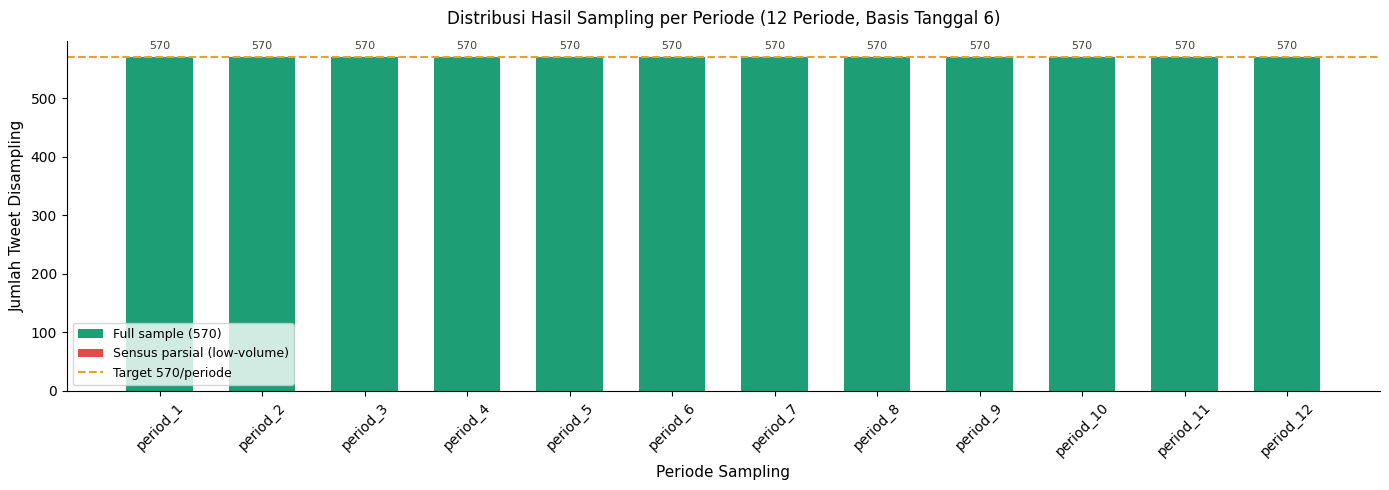

In [12]:
# ── Distribusi hasil sampling by period (12 periode) ─────────────────────────
dist_samp_period = df_log[['period','n_sampled','is_low_volume']].copy()

print('=== DISTRIBUSI HASIL SAMPLING PER PERIODE (12 periode) ===')
print(f'{"Periode":<12} {"n_sampled":>12}  {"Status"}')
print('─' * 40)
for _, row in dist_samp_period.iterrows():
    flag = '⚠️  Sensus parsial' if row['is_low_volume'] else '✅ Full sample'
    print(f'{row["period"]:<12} {row["n_sampled"]:>12,}  {flag}')
print(f'{"-"*40}')
print(f'  {"TOTAL":<11} {dist_samp_period["n_sampled"].sum():>12,}')

# ── Distribusi hasil sampling by month (13 bulan kalender) ───────────────────
# Menggunakan month_key dari df_sampled (bulan aktual created_at)
df_sampled['month_key'] = get_month_key(df_sampled['created_at'])
dist_samp_month = (
    df_sampled.groupby('month_key', observed=True).size()
    .reindex(MONTH_KEYS, fill_value=0).reset_index()
)
dist_samp_month.columns       = ['month_key', 'n_sampled']
dist_samp_month['month_label'] = dist_samp_month['month_key'].map(MONTH_KEY_TO_LABEL)

print(f'\n=== DISTRIBUSI HASIL SAMPLING PER BULAN KALENDER (13 bulan) ===')
print(f'{"Bulan":<18} {"n_sampled":>12}')
print('─' * 33)
for _, row in dist_samp_month.iterrows():
    print(f'{row["month_label"]:<18} {row["n_sampled"]:>12,}')
print(f'{"-"*33}')
print(f'  {"TOTAL":<17} {dist_samp_month["n_sampled"].sum():>12,}')

bar_colors_p = ['#E24B4A' if lv else '#1D9E75'
                for lv in dist_samp_period['is_low_volume']]

# ── Chart 1: by Period (12 bar) ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(dist_samp_period['period'], dist_samp_period['n_sampled'],
              color=bar_colors_p, edgecolor='none', width=0.65)
for bar, val in zip(bars, dist_samp_period['n_sampled']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f'{val:,}', ha='center', va='bottom', fontsize=8, color='#444441')
ax.axhline(y=SAMPLE_PER_PERIOD, color='#EF9F27', linestyle='--', linewidth=1.5)
ax.set_xlabel('Periode Sampling', fontsize=11)
ax.set_ylabel('Jumlah Tweet Disampling', fontsize=11)
ax.set_title(f'Distribusi Hasil Sampling per Periode (12 Periode, Basis Tanggal 6)',
             fontsize=12, pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=45)
ax.legend(handles=[
    Patch(facecolor='#1D9E75', label=f'Full sample ({SAMPLE_PER_PERIOD})'),
    Patch(facecolor='#E24B4A', label='Sensus parsial (low-volume)'),
    plt.Line2D([0],[0], color='#EF9F27', linestyle='--',
               label=f'Target {SAMPLE_PER_PERIOD}/periode')
], fontsize=9)
sns.despine(); plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/distribusi_sampling_per_periode.png',
            dpi=150, bbox_inches='tight')
plt.show()

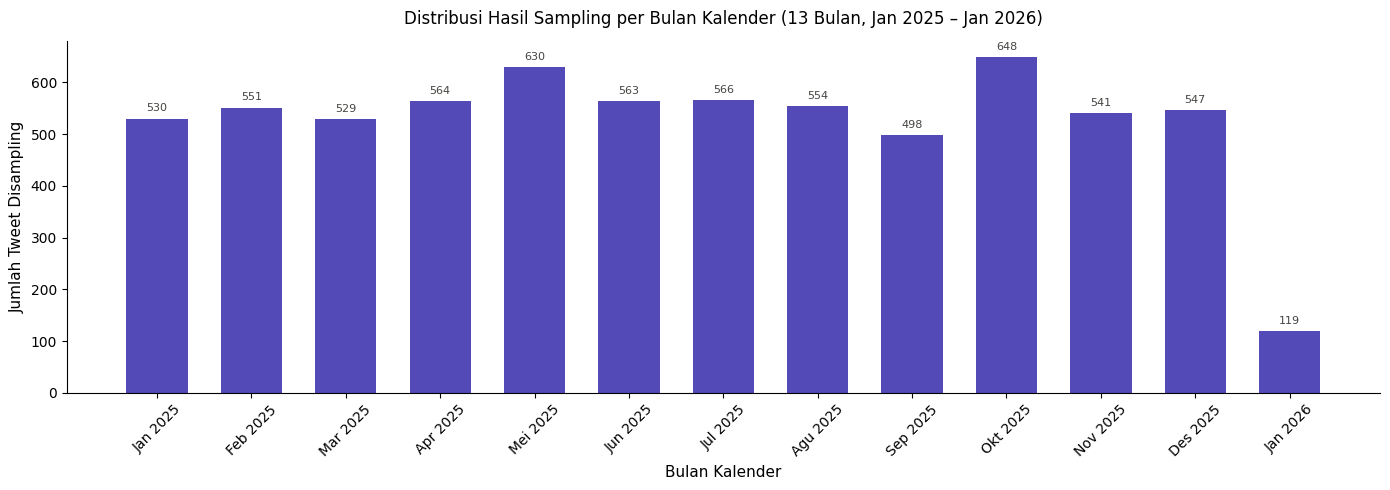

✅ Chart distribusi hasil sampling tersimpan.

=== STATISTIK RINGKASAN SAMPLING ===
Total data siap sampling (12 periode) : 118,340
Total sampel terkumpul                : 6,840
Periode normal (n ≥ 570)          : 12 periode
Periode low-volume (n < 570)       : 0 periode
Overall sampling rate                 : 5.78%

=== STATISTIK PANJANG TWEET (SAMPEL) ===
Mean   : 22.70 kata
Median : 21 kata
Min    : 4 kata
Max    : 61 kata

=== DISTRIBUSI KEYWORD PADA SAMPEL ===
  Total sampel final                :    6,840 tweet
    └─ [makan_bergizi_gratis      ]:    4,544 tweet
    └─ [mbg                       ]:    2,296 tweet


In [13]:
# ── Chart 2: by Month (13 bar) ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.bar(dist_samp_month['month_label'], dist_samp_month['n_sampled'],
              color='#534AB7', edgecolor='none', width=0.65)
for bar, val in zip(bars, dist_samp_month['n_sampled']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
            f'{val:,}', ha='center', va='bottom', fontsize=8, color='#444441')
ax.set_xlabel('Bulan Kalender', fontsize=11)
ax.set_ylabel('Jumlah Tweet Disampling', fontsize=11)
ax.set_title('Distribusi Hasil Sampling per Bulan Kalender (13 Bulan, Jan 2025 – Jan 2026)',
             fontsize=12, pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=45)
sns.despine(); plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/distribusi_sampling_per_bulan.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart distribusi hasil sampling tersimpan.')

# ── Statistik ringkasan ───────────────────────────────────────────────────────
print()
print('=== STATISTIK RINGKASAN SAMPLING ===')
total_avail = df_log['n_available'].sum()
total_samp  = df_log['n_sampled'].sum()
print(f'Total data siap sampling (12 periode) : {total_avail:,}')
print(f'Total sampel terkumpul                : {total_samp:,}')
print(f'Periode normal (n ≥ {SAMPLE_PER_PERIOD})          : {(~df_log["is_low_volume"]).sum()} periode')
print(f'Periode low-volume (n < {SAMPLE_PER_PERIOD})       : {df_log["is_low_volume"].sum()} periode')
print(f'Overall sampling rate                 : {total_samp/total_avail*100:.2f}%')
print(f'\n=== STATISTIK PANJANG TWEET (SAMPEL) ===')
stats = df_sampled['word_count'].describe()
print(f'Mean   : {stats["mean"]:.2f} kata')
print(f'Median : {stats["50%"]:.0f} kata')
print(f'Min    : {stats["min"]:.0f} kata')
print(f'Max    : {stats["max"]:.0f} kata')
print(f'\n=== DISTRIBUSI KEYWORD PADA SAMPEL ===')
print_summary_by_keyword(df_sampled, 'sampel final')

## 8. Export Output

Dataset sampel disimpan ke CSV dengan seluruh kolom yang diperlukan,
diurutkan **ascending by `created_at`**.
Tiga kolom anotasi ditambahkan kosong untuk diisi pada notebook berikutnya.

In [14]:
output_cols = [
    'id_str', 'conversation_id_str', 'created_at', 'period',
    'full_text', 'word_count', 'username', 'user_id_str',
    'favorite_count', 'retweet_count', 'reply_count', 'quote_count',
    'lang', 'location', 'source_keyword'
]
output_cols_exist = [c for c in output_cols if c in df_sampled.columns]
df_final = df_sampled[output_cols_exist].copy()

# Kolom anotasi — diisi pada notebook berikutnya
df_final['label']           = ''  # positive / negative / neutral
df_final['label_roberta']   = ''  # prediksi IndoRoBERTa
df_final['annotator_notes'] = ''  # catatan anotator

# Sort final dan verifikasi
df_final = df_final.sort_values(
    by='created_at', ascending=True).reset_index(drop=True)
is_sorted = df_final['created_at'].is_monotonic_increasing
print(f'Verifikasi urutan ascending: {"✅ SORTED" if is_sorted else "❌ NOT SORTED"}')

df_final.to_csv(OUTPUT_PATH, index=False, encoding='utf-8-sig')

print(f'\n=== OUTPUT BERHASIL DISIMPAN ===')
print(f'Path   : {OUTPUT_PATH}')
print(f'Shape  : {df_final.shape[0]:,} baris × {df_final.shape[1]} kolom')
print(f'Kolom  : {list(df_final.columns)}')
print(f'\nRentang waktu output:')
print(f'  Terlama : {df_final["created_at"].min()}')
print(f'  Terbaru : {df_final["created_at"].max()}')
print(f'\nPreview 3 baris pertama:')
display(df_final[['id_str','created_at','period','full_text',
                   'word_count','source_keyword','label']].head(3))
print(f'\nPreview 3 baris terakhir:')
display(df_final[['id_str','created_at','period','full_text',
                   'word_count','source_keyword','label']].tail(3))

Verifikasi urutan ascending: ✅ SORTED

=== OUTPUT BERHASIL DISIMPAN ===
Path   : /content/drive/My Drive/skripsi/dataset/mbg_2025/processed/mbg_sampled.csv
Shape  : 6,840 baris × 18 kolom
Kolom  : ['id_str', 'conversation_id_str', 'created_at', 'period', 'full_text', 'word_count', 'username', 'user_id_str', 'favorite_count', 'retweet_count', 'reply_count', 'quote_count', 'lang', 'location', 'source_keyword', 'label', 'label_roberta', 'annotator_notes']

Rentang waktu output:
  Terlama : 2025-01-06 02:00:42
  Terbaru : 2026-01-06 23:06:59

Preview 3 baris pertama:


,id_str,created_at,period,full_text,word_count,source_keyword,label
0,1876086460031611206,2025-01-06 02:00:42,period_1,Makan Bergizi Gratis (MBG) mulai diselenggarak...,35,mbg,
1,1876086582341718029,2025-01-06 02:01:11,period_1,Komisi 1 DPRD Kota Blitar Minta Pengusaha Kate...,16,mbg,
2,1876090695590756567,2025-01-06 02:17:32,period_1,Badan Gizi Nasional (BGN) resmi akan memulai P...,21,mbg,



Preview 3 baris terakhir:


,id_str,created_at,period,full_text,word_count,source_keyword,label
6837,2008618298183958991,2026-01-06 19:14:55,period_12,Uangnya bisa utk dana anak sekolah gratis/bang...,48,mbg,
6838,2008667321410425148,2026-01-06 22:29:43,period_12,@yazemogabaiksaj @kelincizen @lalapohlucky @pe...,42,mbg,
6839,2008676701514150372,2026-01-06 23:06:59,period_12,@tempodotco Yg ditemukan di Dapur MBG orang yg...,17,mbg,


## 9. EDA: Distribusi Panjang Token Dataset Final

Distribusi panjang token (proxy: word count) sebelum preprocessing.
Garis batas `max_len = 128` menunjukkan proporsi tweet yang berpotensi terpotong
saat tokenisasi IndoBERT `indobenchmark/indobert-base-p2`.

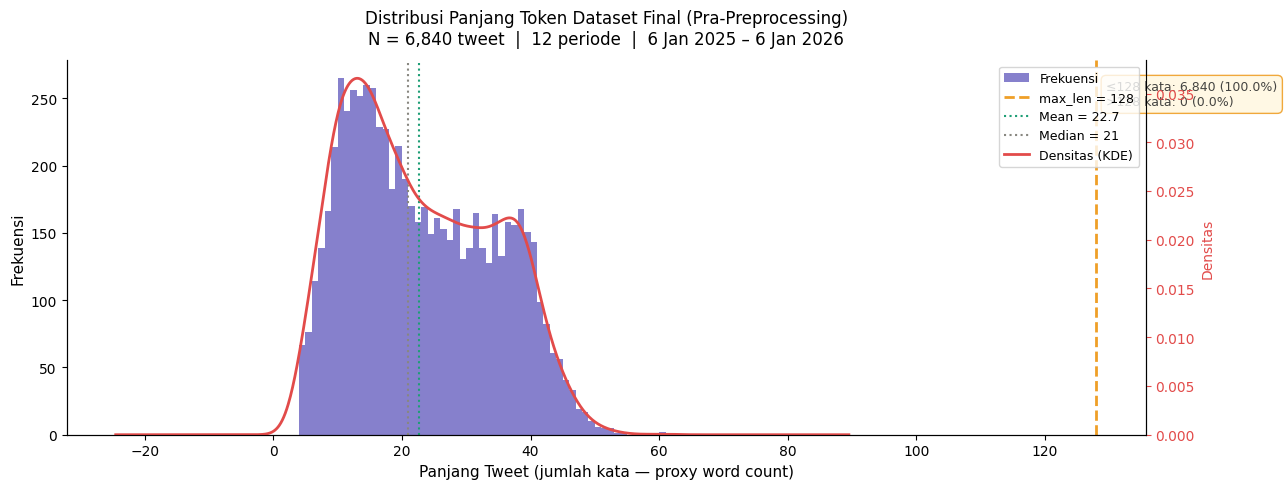

=== STATISTIK DISTRIBUSI PANJANG TOKEN ===
Total tweet                    : 6,840
Mean panjang                   : 22.70 kata
Median panjang                 : 21 kata
Min                            : 4 kata
Max                            : 61 kata
Dalam batas ≤128 kata    : 6,840 (100.00%)
Melebihi batas >128 kata : 0 (0.00%)


In [15]:
MAX_LEN     = 128
token_len   = df_final['word_count'].dropna().astype(int)
n_total     = len(token_len)
n_within    = (token_len <= MAX_LEN).sum()
n_truncated = (token_len >  MAX_LEN).sum()
pct_within  = n_within    / n_total * 100
pct_trunc   = n_truncated / n_total * 100
mean_val    = token_len.mean()
median_val  = token_len.median()

fig, ax = plt.subplots(figsize=(13, 5))
n_bins = min(60, int(token_len.max() - token_len.min()))
ax.hist(token_len, bins=n_bins, color='#534AB7', alpha=0.7,
        edgecolor='none', density=False, label='Frekuensi')
ax2 = ax.twinx()
token_len.plot.kde(ax=ax2, color='#E24B4A', linewidth=2, label='Densitas (KDE)')
ax2.set_ylabel('Densitas', fontsize=10, color='#E24B4A')
ax2.tick_params(axis='y', colors='#E24B4A')
ax2.set_ylim(bottom=0)
ax.axvline(x=MAX_LEN, color='#EF9F27', linestyle='--', linewidth=2,
           label=f'max_len = {MAX_LEN}')
ax.axvline(x=mean_val, color='#1D9E75', linestyle=':', linewidth=1.5,
           label=f'Mean = {mean_val:.1f}')
ax.axvline(x=median_val, color='#888780', linestyle=':', linewidth=1.5,
           label=f'Median = {median_val:.0f}')
ax.text(MAX_LEN + 1.5, ax.get_ylim()[1] * 0.88,
        f'≤{MAX_LEN} kata: {n_within:,} ({pct_within:.1f}%)\n'
        f'>{MAX_LEN} kata: {n_truncated:,} ({pct_trunc:.1f}%)',
        fontsize=9, color='#444441',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF8E1',
                  edgecolor='#EF9F27', alpha=0.9))
ax.set_xlabel('Panjang Tweet (jumlah kata — proxy word count)', fontsize=11)
ax.set_ylabel('Frekuensi', fontsize=11)
ax.set_title(
    f'Distribusi Panjang Token Dataset Final (Pra-Preprocessing)\n'
    f'N = {n_total:,} tweet  |  12 periode  |  6 Jan 2025 – 6 Jan 2026',
    fontsize=12, pad=12)
lines1, lbl1 = ax.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, lbl1+lbl2, fontsize=9, loc='upper right')
sns.despine(right=False); plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/distribusi_panjang_token.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('=== STATISTIK DISTRIBUSI PANJANG TOKEN ===')
print(f'Total tweet                    : {n_total:,}')
print(f'Mean panjang                   : {mean_val:.2f} kata')
print(f'Median panjang                 : {median_val:.0f} kata')
print(f'Min                            : {token_len.min()} kata')
print(f'Max                            : {token_len.max()} kata')
print(f'Dalam batas ≤{MAX_LEN} kata    : {n_within:,} ({pct_within:.2f}%)')
print(f'Melebihi batas >{MAX_LEN} kata : {n_truncated:,} ({pct_trunc:.2f}%)')

## 10. Summary Akhir

In [16]:
print('=' * 65)
print(' DATA PREPARATION SUMMARY — DATASET MBG')
print('=' * 65)
print(f' Base dir        : {BASE_DIR}')
print(f' {"-"*62}')
print(f' Pipeline per keyword:')
print(f'   Makan Bergizi Gratis  : {len(df_makan):>8,} tweet')
print(f'   MBG                   : {len(df_mbg):>8,} tweet')
print(f' Merged full             : {len(df_full):>8,} tweet')
print_summary_by_keyword(df_full, 'merged full')
print(f' {"-"*62}')
print(f' Pre-filter:')
print(f'   Masuk pre-filter      : {n_pf0:>8,} tweet')
print(f'   Setelah filter null   : {n_pf1:>8,} tweet')
print(f'   Setelah filter panjang: {n_pf2:>8,} tweet')
print(f'   Setelah assign_period : {len(df):>8,} tweet (12 periode)')
print(f' {"-"*62}')
print(f' Stratified Sampling:')
print(f'   Target/periode        : {SAMPLE_PER_PERIOD:>8,} (500 target + 70 buffer)')
print(f'   Periode normal        : {(~df_log["is_low_volume"]).sum():>8} periode')
print(f'   Periode low-volume    : {df_log["is_low_volume"].sum():>8} periode')
print(f' {"-"*62}')
print(f' OUTPUT FINAL (sorted asc): {len(df_final):>8,} tweet')
print_summary_by_keyword(df_final, 'output final')
print(f'\n Distribusi by Period (12):')
print(f' {"Periode":<12} {"N Sampel":>10}')
print(f' {"-"*24}')
for _, row in df_log.iterrows():
    print(f'   {row["period"]:<12} {row["n_sampled"]:>8,}')
print(f' {"-"*24}')
print(f'   {"TOTAL":<12} {df_log["n_sampled"].sum():>8,}')
print(f'\n Distribusi by Month (13):')
print(f' {"Bulan":<18} {"N Sampel":>10}')
print(f' {"-"*30}')
for _, row in dist_samp_month.iterrows():
    print(f'   {row["month_label"]:<18} {row["n_sampled"]:>8,}')
print(f' {"-"*30}')
print(f'   {"TOTAL":<18} {dist_samp_month["n_sampled"].sum():>8,}')
print(f' {"-"*62}')
print(f' Urutan output   : ascending created_at '
      f'(verified: {df_final["created_at"].is_monotonic_increasing})')
print(f' Random seed     : {RANDOM_SEED}')
print(f' Output          : {OUTPUT_PATH}')
print('=' * 65)
print('\n Langkah selanjutnya (notebook 02 — Preprocessing & Anotasi):')
print('  1. Buka mbg_sampled.csv')
print('  2. Prediksi IndoRoBERTa → isi kolom label_roberta')
print('  3. Anotasi manual → isi kolom label')
print("  4. Hitung Cohen's Kappa antara label dan label_roberta")

 DATA PREPARATION SUMMARY — DATASET MBG
 Base dir        : /content/drive/My Drive/skripsi/dataset/mbg_2025
 --------------------------------------------------------------
 Pipeline per keyword:
   Makan Bergizi Gratis  :   41,933 tweet
   MBG                   :   80,684 tweet
 Merged full             :  119,380 tweet
  Total merged full                 :  119,380 tweet
    └─ [mbg                       ]:   77,447 tweet
    └─ [makan_bergizi_gratis      ]:   41,933 tweet
 --------------------------------------------------------------
 Pre-filter:
   Masuk pre-filter      :  119,380 tweet
   Setelah filter null   :  119,380 tweet
   Setelah filter panjang:  118,340 tweet
   Setelah assign_period :  118,340 tweet (12 periode)
 --------------------------------------------------------------
 Stratified Sampling:
   Target/periode        :      570 (500 target + 70 buffer)
   Periode normal        :       12 periode
   Periode low-volume    :        0 periode
 ----------------------------

---

## Catatan Metodologis untuk Laporan

### Normalisasi Format `created_at`
Raw data Twitter mengandung dua format timestamp berbeda:
ISO 8601 (`2025-10-07T23:59:35.000Z`) dan format Twitter standar
(`Wed Jan 08 23:26:55 +0000 2025`).
Seluruh format dinormalisasi ke **tz-naive UTC** menggunakan `pd.to_datetime`
dengan `format='mixed', utc=True` dilanjutkan `tz_localize(None)`.
Normalisasi dilakukan sebagai langkah pertama sebelum operasi filter,
deduplikasi, dan assignment periode.

### Alur Data yang Benar
- `df_full` (119,380): dataset gabungan setelah merge dan dedup lintas-keyword
- `df` (±118,340): dataset siap sampling setelah pre-filter null dan panjang
- `df_sampled`: hasil stratified sampling dari `df`
- `df_final`: output akhir tersusun dengan kolom anotasi, sorted ascending

### Definisi Periode Sampling
Periode sampling ditetapkan berbasis tanggal 6 setiap bulan untuk konsistensi
rentang antara 28–31 hari per periode tanpa bergantung pada hari kalender.
Terdapat 12 periode dari 6 Januari 2025 hingga 6 Januari 2026.

### Strategi Sampling
**Equal allocation stratified sampling** dengan strata waktu per periode memastikan
representasi temporal yang merata — tidak ada periode yang mendominasi.

### Justifikasi 570 Tweet per Periode
- **500 tweet**: kecukupan statistik (MoE ≤4.4%, α=0.05, Cochran 1977)
- **70 tweet (14%)**: buffer kurasi dalam rentang rekomendasi NLP annotation (10–20%)

### Pipeline Deduplikasi Berlapis
1. Dedup by `id_str` — duplikat tweet identik (Primary Key)
2. Dedup by teks ternormalisasi — konten sama meski ID berbeda
3. Dedup lintas-dataset — tweet terekam oleh kedua kelompok keyword